In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Import Libraries**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from itertools import cycle
import seaborn as sns
import time
from tqdm.notebook import tqdm
import pandas as pd
import os
import glob
from PIL import Image
import PIL

# **Configuration**

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [32]:
train_batch = 32
test_batch = 16
learning_rate = 0.0001
decay = 1e-4
num_classes = 5
epoch = 100    
patience = 100 
checkpoints_path = "/kaggle/working/"
data_dir = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"

# **Data Loading and Preprocessing**

In [35]:
def load_sipakmed_data(root_dir):
    file_paths = []
    labels = []
    class_map = {
        'dyskeratotic': 'Dyskeratotic',
        'koilocytotic': 'Koilocytotic',
        'metaplastic': 'Metaplastic',
        'parabasal': 'Parabasal',
        'superficial': 'Superficial'
    }
    print(f"Scanning directory: {root_dir}...")
    for root, dirs, files in os.walk(root_dir):
        root_lower = root.lower()
        if "cropped" in root_lower:
            detected_label = None
            for key, val in class_map.items():
                if key in root_lower:
                    detected_label = val
                    break
            if detected_label:
                for file in files:
                    if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                        full_path = os.path.join(root, file)
                        file_paths.append(full_path)
                        labels.append(detected_label)
    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    
    if not df.empty:
        df['filename_stem'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
        df = df.drop_duplicates(subset=['label', 'filename_stem']).drop(columns=['filename_stem'])
    print(f"Total images found: {len(df)}")
    return df
    
data = load_sipakmed_data(data_dir)
train_df, temp_df = train_test_split(data, test_size=0.30, stratify=data['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Scanning directory: /kaggle/input/cervical-cancer-largest-dataset-sipakmed...
Total images found: 4049
Train: 2834, Val: 607, Test: 608


# **Dataset Class**

In [36]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        unique_labels = sorted(dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        try:
            image = PIL.Image.open(img_path).convert("RGB")
        except:
            image = PIL.Image.new('RGB', (224, 224))
        
        label = self.label_map[self.dataframe.iloc[index]['label']]
        
        if self.transform:
            image = self.transform(image)
        return image, label

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# **Dataloaders**

In [37]:
train_dataset = ImageDataset(train_df, transform=data_transforms['train'])
val_dataset = ImageDataset(val_df, transform=data_transforms['val'])
test_dataset = ImageDataset(test_df, transform=data_transforms['val'])

train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2)
validation_dataloader = DataLoader(val_dataset, batch_size=test_batch, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2)

print("Data Loaders ready.")

Data Loaders ready.


# **Attention Modules (CBAM)**

In [38]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

In [39]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

In [40]:
class CBAM(nn.Module):
    def __init__(self, planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

In [41]:
class AttentionCervicalNet(nn.Module):
    def __init__(self, num_classes):
        super(AttentionCervicalNet, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        # CBAM Attention
        self.attention = CBAM(planes=512)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.classifier(x)
        return x

In [42]:
att_model = AttentionCervicalNet(num_classes).to(device)
optimizer = optim.Adam(att_model.parameters(), lr=learning_rate, weight_decay=decay)
criterion = nn.CrossEntropyLoss()

# **Training**

In [43]:
def train_attention_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25, patience=10):
    best_acc = 0.0
    patience_counter = 0
    
    train_loss_hist = []
    train_acc_hist = []
    val_loss_hist = []
    val_acc_hist = []
    
    start_total = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
            
        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects.double() / total_samples
        train_loss_hist.append(epoch_loss)
        train_acc_hist.append(epoch_acc.item())
        
        # Validation
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_running_corrects.double() / val_total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc.item())
        
        print(f'Epoch {epoch+1} - Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save({'model_state_dict': model.state_dict(), 'val_acc': best_acc}, f"{checkpoints_path}/att_model_best.pth")
            print(f"  [+] Model Saved")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print("Early stopping.")
            break
            
    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

print("Starting Training...")
t_loss, t_acc, v_loss, v_acc = train_attention_model(
    att_model, criterion, optimizer, train_dataloader, validation_dataloader, 
    num_epochs=epoch, patience=patience
)

Starting Training...


Epoch 1/100:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 0.9141 Acc: 0.6535 | Val Loss: 0.5325 Acc: 0.8122
  [+] Model Saved


Epoch 2/100:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 2 - Train Loss: 0.6403 Acc: 0.7632 | Val Loss: 0.4241 Acc: 0.8633
  [+] Model Saved


...

Epoch 98 - Train Loss: 0.0638 Acc: 0.9788 | Val Loss: 0.0893 Acc: 0.9621


Epoch 99/100:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 99 - Train Loss: 0.0444 Acc: 0.9845 | Val Loss: 0.1216 Acc: 0.9555


Epoch 100/100:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 100 - Train Loss: 0.0522 Acc: 0.9809 | Val Loss: 0.1027 Acc: 0.9621


# **Visualization**

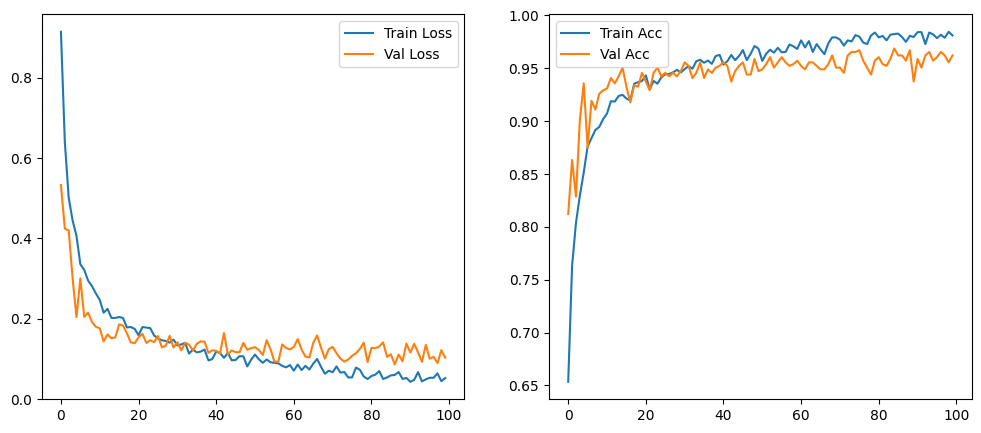

In [44]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_loss, label='Train Loss')
plt.plot(v_loss, label='Val Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t_acc, label='Train Acc')
plt.plot(v_acc, label='Val Acc')
plt.legend()
plt.show()

# **Evaluation**

Loaded best model with Val Acc: 0.9687


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]


Inference Time: 1.44s

Classification Report:
              precision    recall  f1-score   support

Dyskeratotic       0.99      0.93      0.96       122
Koilocytotic       0.91      0.95      0.93       124
 Metaplastic       0.95      0.94      0.95       119
   Parabasal       0.97      1.00      0.98       118
 Superficial       0.98      0.97      0.98       125

    accuracy                           0.96       608
   macro avg       0.96      0.96      0.96       608
weighted avg       0.96      0.96      0.96       608


Per Class Accuracy:
Dyskeratotic: 0.9344
Koilocytotic: 0.9516
Metaplastic: 0.9412
Parabasal: 1.0000
Superficial: 0.9680


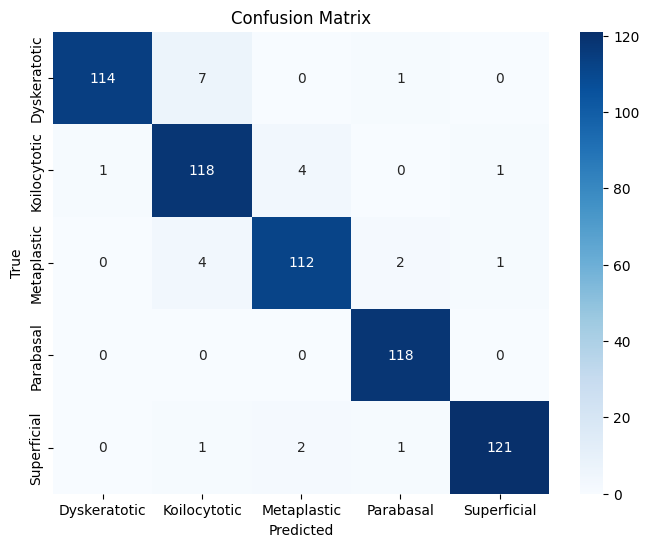

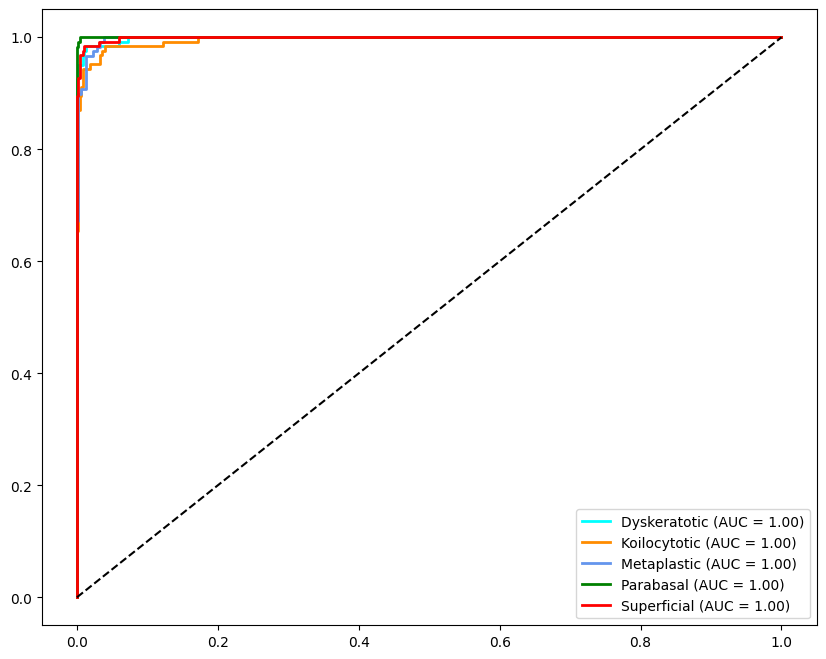

In [48]:
def evaluate_attention_model(model, dataloader, num_classes, class_names):

    checkpoint = torch.load(f"{checkpoints_path}/att_model_best.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model with Val Acc: {checkpoint['val_acc']:.4f}")
    
    model.eval()
    y_true, y_pred, y_score = [], [], []
    
    inference_start = time.time()
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_score.extend(probs.cpu().numpy())
            
    inference_time = time.time() - inference_start
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)
    
    print(f"\nInference Time: {inference_time:.2f}s")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    

    cm = confusion_matrix(y_true, y_pred)
    
    # Diagonal elements are correct predictions, sum(axis=1) is total actuals per class
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nPer Class Accuracy:")
    for i, name in enumerate(class_names):
        print(f"{name}: {per_class_acc[i]:.4f}")

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()
    
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.legend()
    plt.show()

class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']

evaluate_attention_model(att_model, test_dataloader, num_classes, class_names)